<a href="https://colab.research.google.com/github/adamperkins-code/Machine_Learning/blob/main/lecturebook/homework/homework-01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 1

**Coverage:** Lectures 1–4  
**Due:** Sunday, August 30, 2026, 11:59 p.m. ET  
**Total:** 100 points

## Instructions

- Complete this notebook in Google Colab.
- Problem 1 is a manual mathematics problem. Show every important step in
  Markdown/LaTeX, or insert one clearly legible image of your handwritten work.
  Code may check arithmetic only after the derivation is complete.
- Problem 2 is a guided scientific-computing study. Do not delete supplied
  setup or helper cells.
- Your submitted notebook must run from beginning to end in a fresh Colab
  runtime without Google Drive, absolute paths, or additional package
  installation.
- Label plots and include units. Report numerical answers to at least four
  significant digits unless a question states otherwise.

The course material needed for this assignment is collected here:

- [Probability rules and reverse conditioning](https://predictivesciencelab.github.io/data-analytics-se/lecture02/reading-02.html)
- [Continuous random variables, CDFs, PDFs, and expectations](https://predictivesciencelab.github.io/data-analytics-se/lecture04/reading-04.html)
- [The uniform distribution](https://predictivesciencelab.github.io/data-analytics-se/lecture04/hands-on-04.1.html)
- [The Gaussian distribution and its quantiles](https://predictivesciencelab.github.io/data-analytics-se/lecture04/hands-on-04.2.html)

## Student details

- **First name:** Adam
- **Last name:** Perkins
- **Purdue email:** perki235@purdue.edu

In [3]:
import logging

import numpy as np
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=6, suppress=True)

## Problem 1 — Diagnosing a pump from a vibration alarm (25 points)

A centrifugal pump operates under a fixed regime. Its unknown condition is
modeled as exactly one of three states:

- $H$: the pump is healthy;
- $M$: the pump is misaligned;
- $C$: the pump is cavitating.

The three states are mutually exclusive and exhaustive under this simplified
model. Historical operating records give

$$
P(H)=0.96, \qquad P(M)=0.03, \qquad P(C)=0.01.
$$

A vibration monitor returns either an alarm $A$ or no alarm $A^c$. Its
alarm probabilities are

$$
P(A\mid H)=0.05, \qquad
P(A\mid M)=0.80, \qquad
P(A\mid C)=0.95.
$$

The probability $P(A\mid H)$ is the **false-alarm probability**: the monitor
alarms even though the pump is healthy. The corresponding quantity
$P(A^c\mid H)=1-P(A\mid H)$ is the monitor's **specificity**. A probability
conditioned on an observed alarm, such as $P(M\mid A)$, is a **posterior
probability** because it describes the state of knowledge after observing the
alarm. Use the [sum and product rules](https://predictivesciencelab.github.io/data-analytics-se/lecture02/reading-02.html) throughout.

### 1.1 Joint probabilities (6 points)

Construct a table containing all six state-and-monitor outcomes. Calculate
the joint probabilities $P(A,H)$, $P(A,M)$, $P(A,C)$, $P(A^c,H)$,
$P(A^c,M)$, and $P(A^c,C)$, and verify that they sum to one. Here
$P(A,H)$ means $P(A\cap H)$.

Table of possible states:

$$
\begin{array}{|c|c|c|}
\hline
\text{Pump Healthy, Alarm on} & \text{Pump Misaligned, Alarm on} & \text{Pump Cavitating, Alarm on} \\
\hline
\text{Pump Healthy, Alarm off} & \text{Pump Misaligned, Alarm off} & \text{Pump Cavitating, Alarm off} \\
\hline
\end{array}
$$

Joint Probabilities:
$$
\begin{array}{|c|c|}
\hline
\text{P(A,H)} & \text{P(A|H)*P(H) = 0.048} \\
\hline
\text{P(A,M)} & \text{P(A|M)*P(M) = 0.024} \\
\hline
\text{P(A,C)} & \text{P(A|C)*P(C) = 0.0095} \\
\hline
\text{P(A}^c\text{,H)} & \text{(1 - P(A|H))*P(H) = 0.912} \\
\hline
\text{P(A}^c\text{,M)} & \text{(1 - P(A|M))*P(M) = 0.006} \\
\hline
\text{P(A}^c\text{,C)} & \text{(1 - P(A|C))*P(C) = 0.0005} \\
\hline
\text{SUM:} & \text{1.0} \\
\hline
\end{array}
$$

### 1.2 Posterior diagnosis (8 points)

Calculate $P(H\mid A)$, $P(M\mid A)$, $P(C\mid A)$, and
$P(M\text{ or }C\mid A)$. Show the symbolic numerator and denominator before
substituting numerical values.

To calculate $P(A)$, I'm going to add up the cells from the state table that include the alarm going off. That is, $P(A) = P(A,H)+P(A,M)+P(A,C) = 0.048+0.024+0.0095=0.0815$

$$
\begin{array}{|c|c|}
\hline
\text{P(H|A)} & \left( \dfrac{P(A|H)*P(H)}{P(A)} \right)= \left( \dfrac{0.05*0.96}{0.0815} \right)=0.58896\\
\hline
\text{P(M|A)} & \left( \dfrac{P(A|M)*P(M)}{P(A)} \right)= \left( \dfrac{0.8*0.03}{0.0815} \right)=0.29448\\
\hline\
\text{P(C|A)} & \left( \dfrac{P(A|C)*P(C)}{P(A)} \right)= \left( \dfrac{0.95*0.01}{0.0815} \right)=0.1165\\
\hline
\text{P(M or C|A)} & \text{P(M|A)+P(C|A)= 0.4110} \\
\hline
\end{array}
$$


### 1.3 Interpretation (4 points)

Compare the prior probability of a fault, $P(M\text{ or }C)$, with its
posterior probability after an alarm. Then explain why $H$ is still the most
probable individual state after an alarm.

$P(M \text{ or }C)=P(M)+P(C)=0.03+0.01=\mathbf{0.04}, \text{ }P(M \text{ or }C|A)=\mathbf{0.4110}\\
P(H|A)=\mathbf{0.58896}\\
 P(H|A)>P(M \text{ or }C|A)$

### 1.4 Monitor design (7 points)

A redesigned monitor keeps $P(A\mid M)=0.80$ and $P(A\mid C)=0.95$, while
its false-alarm probability is $q=P(A\mid H)$. Derive the largest $q$ for
which $P(M\text{ or }C\mid A)\geq0.90$. Report the corresponding minimum
specificity, and explain the practical significance of the requirement.

## Problem 2 — Fatigue life of an aluminum alloy (75 points)

Rectangular specimens of 6061-T6 aluminum were subjected to repeated loading
with a maximum stress of $21{,}000$ psi. The recorded quantity is the number
of cycles until rupture, measured in thousands of cycles. The 101 observations
come from the NIST fatigue-life case study and were originally reported by
Birnbaum and Saunders.

- [NIST description and complete data](https://www.itl.nist.gov/div898/handbook/eda/section4/eda4291.htm)
- [Original study](https://doi.org/10.1080/01621459.1958.10501433)

We will compare three probability models and use them to answer a replacement
question. No model is declared correct in advance.

Let $T>0$ denote fatigue life. Its cumulative distribution function (CDF) is

$$
F(t)=P(T\leq t).
$$

The **survival function** is

$$
S(t)=P(T>t)=1-F(t).
$$

Thus, $S(t)$ is the probability that a specimen has not ruptured after $t$
thousand loading cycles.

For observed fatigue lives $t_1,\ldots,t_n$, the **empirical CDF** is

$$
\widehat F_n(t)=\frac{1}{n}\sum_{i=1}^n
\mathbf{1}(t_i\leq t),
$$

where $\mathbf{1}(t_i\leq t)$ equals one when $t_i\leq t$ and zero
otherwise. Thus, $\widehat F_n(t)$ is the observed fraction that failed by
age $t$. The empirical survival function is
$\widehat S_n(t)=1-\widehat F_n(t)$.

In [4]:
# Fatigue life in thousands of cycles. The values are embedded so that the
# notebook remains reproducible if the external source is unavailable.
fatigue_life = np.array([
     370, 1016, 1235, 1419, 1567, 1820,
     706, 1018, 1238, 1420, 1578, 1868,
     716, 1020, 1252, 1420, 1594, 1881,
     746, 1055, 1258, 1450, 1602, 1890,
     785, 1085, 1262, 1452, 1604, 1893,
     797, 1102, 1269, 1475, 1608, 1895,
     844, 1102, 1270, 1478, 1630, 1910,
     855, 1108, 1290, 1481, 1642, 1923,
     858, 1115, 1293, 1485, 1674, 1940,
     886, 1120, 1300, 1502, 1730, 1945,
     886, 1134, 1310, 1505, 1750, 2023,
     930, 1140, 1313, 1513, 1750, 2100,
     960, 1199, 1315, 1522, 1763, 2130,
     988, 1200, 1330, 1522, 1768, 2215,
     990, 1200, 1355, 1530, 1781, 2268,
    1000, 1203, 1390, 1540, 1782, 2440,
    1010, 1222, 1416, 1560, 1792,
], dtype=float)


def empirical_cdf(sample, grid):
    """Evaluate the empirical CDF of a one-dimensional sample on a grid.

    Arguments:
    sample -- The observed data values.
    grid   -- The values at which to evaluate the empirical CDF.
    """
    sample = np.asarray(sample, dtype=float)
    grid = np.asarray(grid, dtype=float)
    return np.mean(sample[:, None] <= grid[None, :], axis=0)


def uniform_discrepancy(values):
    """Return the maximum vertical gap from the uniform CDF on [0, 1].

    Arguments:
    values -- The transformed observations to compare with the uniform CDF.
    """
    ordered = np.sort(np.asarray(values, dtype=float))
    n = ordered.size
    gap_above = np.arange(1, n + 1) / n - ordered
    gap_below = ordered - np.arange(n) / n
    return max(np.max(gap_above), np.max(gap_below))


print(f"Loaded {fatigue_life.size} observed fatigue lives.")

Loaded 101 observed fatigue lives.


### 2.1 Empirical reliability (10 points)

1. **Summary (2 points).** Report the number, minimum, median, and maximum of
   the observed fatigue lives.
2. **Empirical survival (5 points).** Plot the empirical survival function for
   the observed fatigue-life data. Mark every observed fatigue life along the
   horizontal axis.
3. **Interpretation (3 points).** Calculate the observed fraction that
   survived beyond one million cycles and explain why the empirical survival
   function decreases in steps.

Number of Fatigue Lives: 101
Min Fatigue life: 370.0 thousand cycles
Median Fatigue Life: 1416.0 thousand cycles
Max Fatigue Life: 2440.0 thousand cycles
Fraction of fatigue lives greater than one million: 0.8415841584158416
The empirical survival function decreases in steps because it is based off discreet data points


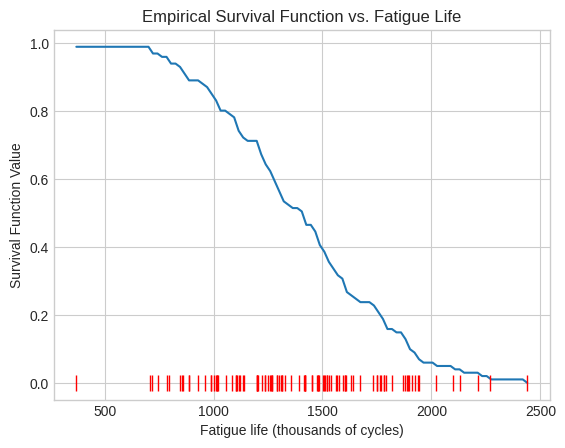

In [32]:

#Calc basic info
num_fatigue_lives = fatigue_life.size
min_fatigue_life = min(fatigue_life)
median_fatigue_life = np.median(fatigue_life)
max_fatigue_life = max(fatigue_life)


print(f"Number of Fatigue Lives: {num_fatigue_lives}")
print(f"Min Fatigue life: {min_fatigue_life} thousand cycles")
print(f"Median Fatigue Life: {median_fatigue_life} thousand cycles")
print(f"Max Fatigue Life: {max_fatigue_life} thousand cycles")


sample_grid = np.linspace(min_fatigue_life,
                          max_fatigue_life,num=num_fatigue_lives)
cdf = empirical_cdf(fatigue_life,sample_grid)

#Plotting
plt.figure
plt.plot(sample_grid,1-cdf)
plt.plot(fatigue_life, np.zeros_like(fatigue_life), '|', color='red',
         markersize=12, label='Observed Values')
plt.xlabel('Fatigue life (thousands of cycles)')
plt.ylabel('Survival Function Value')
plt.title('Empirical Survival Function vs. Fatigue Life')
plt.grid(True)

#Calculating fraction above 1 million cycles
above_1_million = fatigue_life[fatigue_life>1000]
frac_above_1_million = above_1_million.size/num_fatigue_lives
print(f"Fraction of fatigue lives greater than one million: {frac_above_1_million}")
print("The empirical survival function decreases in steps because it is based off discreet data points")

### Candidate lifetime models

The first candidate is a two-parameter
[Weibull distribution](https://en.wikipedia.org/wiki/Weibull_distribution):

$$
F_W(t)=
\begin{cases}
0, & t<0,\\[2mm]
1-\exp\!\left[-\left(\dfrac{t}{\lambda}\right)^k\right], & t\geq0,
\end{cases}
$$

where $k>0$ is a dimensionless shape parameter and $\lambda>0$ is a scale
parameter with the same units as $T$.

The second candidate is a two-parameter lognormal model. For $t$ expressed in
thousands of cycles, its CDF is

$$
F_L(t)=
\begin{cases}
0, & t\leq0,\\[2mm]
\Phi\!\left(\dfrac{\log t-\mu_L}{\sigma_L}\right), & t>0,
\end{cases}
$$

where $\log$ is the natural logarithm, $\mu_L$ is the mean of $\log T$,
$\sigma_L>0$ is its standard deviation, and $\Phi$ is the standard Gaussian
CDF introduced in [Lecture 4](https://predictivesciencelab.github.io/data-analytics-se/lecture04/hands-on-04.2.html). The quantity
$\eta=\exp(\mu_L)$ is the lognormal scale parameter and has the same units as
$T$.

The third candidate is an exponential model:

$$
F_E(t)=
\begin{cases}
0, & t<0,\\[2mm]
1-\exp\!\left(-\dfrac{t}{\beta}\right), & t\geq0,
\end{cases}
$$

where $\beta>0$ is both the scale parameter and the mean lifetime. The
exponential model is the special case $k=1$ of the Weibull model. All three
models assign probability only to nonnegative lifetimes.

The models contain unknown parameters. Assuming the observations are
independent draws from one distribution, **maximum-likelihood fitting** chooses
the parameter values under which the observed sample has the largest joint
probability density. The fitting calls below are supplied; the theory of
maximum likelihood is not assessed in this assignment. Fixing `floc=0.0`
enforces the stated nonnegative support and gives the parameterizations above.

In [34]:
weibull_shape_hat, _, weibull_scale_hat = stats.weibull_min.fit(
    fatigue_life, floc=0.0
)
lognormal_shape_hat, _, lognormal_scale_hat = stats.lognorm.fit(
    fatigue_life, floc=0.0
)
lognormal_mu_hat = np.log(lognormal_scale_hat)
_, exponential_scale_hat = stats.expon.fit(fatigue_life, floc=0.0)

weibull_model = stats.weibull_min(
    weibull_shape_hat, loc=0.0, scale=weibull_scale_hat
)
lognormal_model = stats.lognorm(
    lognormal_shape_hat, loc=0.0, scale=lognormal_scale_hat
)
exponential_model = stats.expon(loc=0.0, scale=exponential_scale_hat)

print("The three candidate models are fitted and ready for analysis.")

The three candidate models are fitted and ready for analysis.


### 2.2 Fitted models (20 points)

1. **Parameters and probabilities (8 points).** Report the fitted parameters
   with units. For each model, calculate the mean, median, and
   $P(1000<T<1800)$.
2. **Survival comparison (12 points).** Re-create the empirical-survival plot
   from Part 2.1 and overlay all three fitted survival functions. Identify any
   model that is visibly inconsistent with the data. For the Weibull and
   lognormal models, calculate the largest absolute difference in survival
   probability over 0 to 2600 thousand cycles and report approximately where
   it occurs.

In [ ]:
# YOUR CODE HERE

> **Response:** Replace this text with your work.

### 2.3 Turning a model check into a uniformity check (20 points)

A CDF provides a useful model diagnostic. Suppose $T$ truly has a continuous
CDF $F$ that is strictly increasing over the values $T$ can take. Let
$F^{-1}$ denote its inverse, also called its quantile function, and define
$U=F(T)$. For $0<u<1$,

$$
P(U\leq u)
=P\!\left(T\leq F^{-1}(u)\right)
=F\!\left(F^{-1}(u)\right)
=u.
$$

The endpoint cases $u=0$ and $u=1$ follow directly. Thus, $U$ follows the
[uniform distribution on $[0,1]$](https://predictivesciencelab.github.io/data-analytics-se/lecture04/hands-on-04.1.html). This calculation is called the
**probability-integral transform**.

For each fitted model, transform every observed fatigue life using its fitted CDF.
If a model describes the data well, the transformed values should be spread
approximately uniformly between zero and one. We will make a descriptive
comparison; the parameters were fitted using the same observations, so the
calculation below is not a formal hypothesis test. Fitting on these observations
tends to make the discrepancy smaller, so we use it only as a descriptive
distance and do not compare it with a standard cutoff.

1. **CDF implementation (8 points).** Implement the Weibull, lognormal, and
   exponential CDF formulas yourself. Each function must accept a NumPy array,
   return an array of the same shape, and include a docstring following the
   course convention. You may call `stats.norm.cdf` only for the standard
   Gaussian CDF $\Phi$ appearing inside the lognormal CDF. Verify your
   implementations against the supplied fitted SciPy objects at
   $t=-100,500,1000,1500,2000$, and report the largest absolute discrepancy
   for each model.
2. **Transformed histograms (6 points).** Transform the 101 observations with
   each fitted CDF. Make three count histograms with ten equal-width bins on
   $[0,1]$. Under exact uniformity, the expected count is
   $101/10=10.1$ observations per bin.
3. **Descriptive comparison (6 points).** Apply the supplied
   `uniform_discrepancy` function. It returns the maximum
   vertical distance $D$ between the empirical CDF of the transformed values
   and the uniform CDF. A smaller $D$ indicates closer descriptive agreement.
   Compare the three models, identify any model that is clearly inconsistent
   with the data, and state which models you would carry into the replacement
   calculation. Do not attach a $p$-value or declare any model true.

In [ ]:
# YOUR CODE HERE

> **Response:** Replace this text with your work.

### 2.4 A tail-sensitive replacement decision (15 points)

A design team provisionally treats the specimen lifetimes as representative of a
component operating under the same loading condition. The proposed policy
replaces the component after 300 thousand cycles. Within a fitted model, the
policy meets its target when the probability of rupture before replacement is
at most $0.001$, or $0.1\%$. Based on your Part 2.3 comparison, use the two
models with the smaller $D$ scores as the decision candidates. Analyze the
remaining model separately in item 3 below.

1. **Proposed policy (4 points).** Calculate the predicted risk at 300 thousand
   cycles under each decision candidate, and decide whether the proposal
   passes under each model.
2. **Model-based ages (4 points).** Calculate the latest replacement age
   satisfying the target under each decision candidate. If the policy must
   satisfy both candidates, state the resulting replacement age. Compare both
   model-based ages with the smallest observed fatigue life.
3. **The remaining model (3 points).** Calculate the remaining model's
   predicted risk at 300 thousand cycles and its latest age satisfying the
   target. Explain how the model check in Part 2.3 should affect the use of
   these numbers in the policy decision.
4. **Strength of the conclusion (4 points).** State whether the calculations
   provide a 99.9% reliability guarantee. In your explanation, compare the
   target probability $0.001$ with $1/101$, the empirical-probability change
   contributed by one observation.

In [ ]:
# YOUR CODE HERE

> **Response:** Replace this text with your work.

### 2.5 Scope of the conclusion (10 points)

In no more than four sentences, state one specific limitation of using these
specimen experiments to set a replacement policy for an actual component.
Identify additional data or experimental information that would address the
limitation. Your answer must refer to the experimental setting or the
model-based tail calculation rather than merely saying that more data are
needed.

> **Response:** Replace this text with your work.